# Heidi's code

# Heidi's code: s1_make_gal_cat_mstar.py

## Save gals_m500c.fit catalog
## Mstar_lim = 2e+10
## sel_halo = M500c_list > 5e14

In [1]:
#!/usr/bin/env python
import numpy as np
import matplotlib.pyplot as plt
import h5py
from astropy.io import fits
import os, sys
# from get_flamingo_info import get_flamingo_cosmo, get_snap_name
from hod.utils.get_flamingo_info import get_flamingo_cosmo, get_snap_name


redshift = 0.3 #0.4 #0.3

sim_name = 'L1000N3600/HYDRO_FIDUCIAL'
input_loc = f'/cosma8/data/dp004/flamingo/Runs/{sim_name}/'
# output_loc = f'/cosma8/data/do012/dc-wu5/cylinder/output_{sim_name}/z{redshift}/'
output_loc = f'/cosma8/data/do012/dc-yang8/data/output_{sim_name}/z{redshift}/'

if os.path.isdir(output_loc) == False: 
    os.makedirs(output_loc)
    print(output_loc)

halo_finder = 'HBT' # 'VR'

scale_factor = 1./(1.+redshift)
snap_name = get_snap_name(sim_name, redshift)

cosmo = get_flamingo_cosmo(sim_name)
hubble = cosmo['h']
print('hubble', hubble)
if halo_finder == 'HBT':
    fname = input_loc + f'SOAP-HBT/halo_properties_{snap_name}.hdf5'
if halo_finder == 'VR':
    fname = input_loc + f'SOAP-VR/halo_properties_{snap_name}.hdf5'

#### select galaxies with a Mstar limit 
#### Performing galaxy-halo matching using R500c 
#### Save a galaxy catalog with griz bands (for futher selection)

Mstar_lim = 2e+10
output_loc = output_loc+f'/model_mstar{Mstar_lim:.0e}_{halo_finder}/'
if os.path.isdir(output_loc) == False: 
    os.makedirs(output_loc)

f = h5py.File(fname,'r')

#### read subhalo properties ####
if halo_finder == 'HBT':
    id_halofinder = f['InputHalos/HaloCatalogueIndex'][:]
    M500c_list = f['SO/500_crit/TotalMass'][:] * 1e10 * hubble
if halo_finder == 'VR':
    id_halofinder = f['VR/ID'][:]
    M500c_list = f['SO/500_crit/TotalMass'][:] * hubble

R500c_list = f['SO/500_crit/SORadius'][:] * hubble 

if halo_finder == 'HBT':
    pos = f['InputHalos/HaloCentre']
if halo_finder == 'VR':
    pos = f['VR/CentreOfPotential']

x_list = pos[:,0] * hubble
y_list = pos[:,1] * hubble
z_list = pos[:,2] * hubble
if halo_finder == 'HBT':
    vel = f['BoundSubhalo/CentreOfMassVelocity']
if halo_finder == 'VR':
    vel = f['BoundSubhaloProperties/CentreOfMassVelocity']
    
vx_list = vel[:,0]
vy_list = vel[:,1]
vz_list = vel[:,2]

#### select galaxies
if halo_finder == 'HBT':
    Mstar_list = f['BoundSubhalo/StellarMass'][:] * 1e10
    L = f['BoundSubhalo/StellarLuminosity']  #u, g, r, i, z, Y, J, H, K
if halo_finder == 'VR':
    Mstar_list = f['BoundSubhaloProperties/StellarMass'][:]
    L = f['BoundSubhaloProperties/StellarLuminosity']  #u, g, r, i, z, Y, J, H, K
    
L_g_list = L[:,1]
L_r_list = L[:,2]
L_i_list = L[:,3]
L_z_list = L[:,4]


sel_gal = (Mstar_list > Mstar_lim)&(L_g_list > 0)&(L_r_list > 0)&(L_i_list > 0)&(L_z_list > 0)

x_gal = x_list[sel_gal]
y_gal = y_list[sel_gal]
z_gal = z_list[sel_gal]
vx_gal = vx_list[sel_gal]
vy_gal = vy_list[sel_gal]
vz_gal = vz_list[sel_gal]
id_gal = id_halofinder[sel_gal]
M500c_gal = M500c_list[sel_gal] # Zero for subhalo. used later for percolation

# Absolute AB magnitude. see the SOAP manual
M_g = -2.5 * np.log10(L_g_list[sel_gal])
M_r = -2.5 * np.log10(L_r_list[sel_gal])
M_i = -2.5 * np.log10(L_i_list[sel_gal])
M_z = -2.5 * np.log10(L_z_list[sel_gal])

# is a central galaxy nor not
# structype = f['VR/StructureType'][:][sel_gal]
# iscen = np.zeros(len(structype))
# iscen[structype == 10] = 1
#iscen = f['InputHalos/IsCentral'][:]


#### select halos (for matching purposes) ####
sel_halo = M500c_list > 5e14 #2e11 # 5e14; 3e14
x_halo = x_list[sel_halo]
y_halo = y_list[sel_halo]
z_halo = z_list[sel_halo]
id_halo = id_halofinder[sel_halo]
M500c_halo = M500c_list[sel_halo]
R500c_halo = R500c_list[sel_halo]

##### Match galaxies to halos using R500c ####
boxsize = 1000 * hubble

from scipy import spatial

rmax_tree = max(R500c_halo)+0.1 ### R500c; 5R500c
gal_position = np.dstack([x_gal, y_gal, z_gal])[0]
gal_tree = spatial.cKDTree(gal_position, boxsize=boxsize)

halo_position = np.dstack([x_halo, y_halo, z_halo])[0]
halo_tree = spatial.cKDTree(halo_position, boxsize=boxsize)

indexes_tree = halo_tree.query_ball_tree(gal_tree, r=rmax_tree)

nhalo = len(M500c_halo)
Ngal = []

ntot = len(x_gal)
id_host = np.zeros(ntot)
M500c_host = np.zeros(ntot)

for i_halo in range(nhalo):
    gal_ind = indexes_tree[i_halo]
    x_cen = x_halo[i_halo]
    y_cen = y_halo[i_halo]
    z_cen = z_halo[i_halo]
    R500c = R500c_halo[i_halo]
    M500c = M500c_halo[i_halo]
    hid = id_halo[i_halo]
    indx = gal_tree.query_ball_point([x_cen, y_cen, z_cen], R500c)
    Ngal.append(len(indx))

    M500c_host[indx] = M500c
    id_host[indx] = hid


##### Save the galaxy file #####

#print('frac', len(M500c_host[M500c_host==0])/len(M500c_host))
### 10% galaxies have host mass < 2e10.  Disgard them??
#sel_gal = (M500c_host > 2e11)

cols=[
  #fits.Column(name='hid_host', format='K', array=id_host),
  #fits.Column(name='hid_sub', format='K', array=id_gal),
  fits.Column(name='mass_host', unit='M500c, Msun/h', format='E', array=M500c_host),
  #fits.Column(name='mass_sub', unit='M500c, Msun/h', format='E', array=M500c_gal), # good redundancy
  fits.Column(name='px', unit='Mpc/h', format='D', array=x_gal),
  fits.Column(name='py', unit='Mpc/h', format='D', array=y_gal),
  fits.Column(name='pz', unit='Mpc/h', format='D', array=z_gal),
  fits.Column(name='vx', format='D', array=vx_gal),
  fits.Column(name='vy', format='D', array=vy_gal),
  fits.Column(name='vz', format='D', array=vz_gal),
  #### Magnitude information ####
  fits.Column(name='M_g', unit='', format='D', array=M_g),
  fits.Column(name='M_r', unit='', format='D', array=M_r),
  fits.Column(name='M_i', unit='', format='D', array=M_i),
  fits.Column(name='M_z', unit='', format='D', array=M_z),
  #fits.Column(name='iscen', unit='', format='K',array=iscen),
]
coldefs = fits.ColDefs(cols)
tbhdu = fits.BinTableHDU.from_columns(coldefs)
fname = f'gals_m500c.fit'
tbhdu.writeto(f'{output_loc}/{fname}', overwrite=True)

print("Mg", min(M_g), max(M_g))
print("Mr", min(M_r), max(M_r))
print("Mi", min(M_i), max(M_i))
print("Mz", min(M_z), max(M_z))
print(len(M_z))

hubble 0.681
Mg -27.81844 -19.227406
Mr -28.26984 -20.036469
Mi -28.497967 -20.377333
Mz -28.712456 -20.683632
4890455


In [2]:
len(M_z)/boxsize**3

0.015484883108289731

# Heidi: flamingo/galaxies/s2_make_gal_cat_red_3band.py

## chi_cut = 6 #2  #default is 6 
## Mstar_lim = 2e+10
## Plot: M_z_lim: dM = 0.5  for M_z_lim in np.arange(-25, -22, dM):

Mz -28.71245574951172 -20.683631896972656
          gr        ri        iz
gr  1.000000  0.976618  0.811951
ri  0.976618  1.000000  0.904796
iz  0.811951  0.904796  1.000000
sel_num_gal 3420
Mz -28.71245574951172 -20.683631896972656


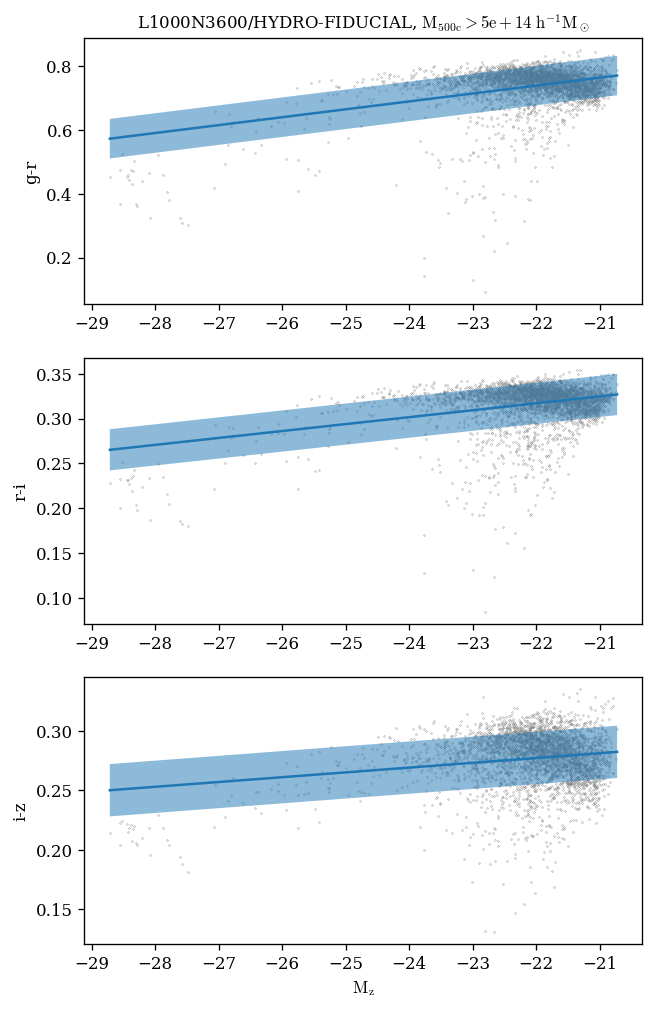

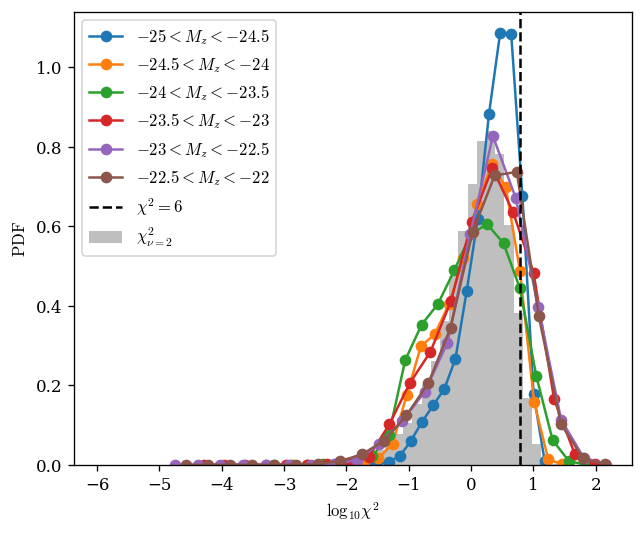

In [42]:
#!/usr/bin/env python
import numpy as np
import matplotlib.pyplot as plt
# plt.style.use('MNRAS')
#import h5py
import fitsio
import pandas as pd
import os, sys
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'

redshift = 0.3 #0.4 #0.4 #0.3

sim_name = 'L1000N3600/HYDRO_FIDUCIAL'
halo_finder = 'HBT' #'VR'
sim_label = sim_name.replace('/','_')
plot_loc = f'../../plots/galaxies/{sim_label}/z{redshift}/'
if os.path.isdir(plot_loc) == False: 
    os.makedirs(plot_loc)

###########################################
chi_cut = 6 #default:6 #2  #default is 6 
###########################################
Mstar_lim = 2e+10
# master_loc = f'/cosma8/data/do012/dc-wu5/cylinder/output_{sim_name}/z{redshift}/'
master_loc = f'/cosma8/data/do012/dc-yang8/data/output_{sim_name}/z{redshift}/'

input_loc = master_loc + f'/model_mstar{Mstar_lim:.0e}_{halo_finder}/'
data, header = fitsio.read(f'{input_loc}/gals_m500c.fit', header=True)
#print(header)
mass_host = data['mass_host']
M_g = data['M_g'].flatten()
M_r = data['M_r'].flatten()
M_i = data['M_i'].flatten()
M_z = data['M_z'].flatten()
gr = M_g - M_r
ri = M_r - M_i
iz = M_i - M_z

print("Mz", min(M_z), max(M_z))

color_list = np.array([gr, ri, iz])
color_name_list = ['g_r', 'r_i', 'i_z']

#### correlation coefficient
df = pd.DataFrame({'gr': gr, 'ri': ri, 'iz': iz})
correlation_matrix = df.corr()
print(correlation_matrix)
Cov = df.cov()
Cov = np.array(Cov)
iCov = np.linalg.inv(Cov)

#### fit the red-sequence with a straight line ####
# plt.figure(figsize=(4,6))
fig = plt.figure(figsize=(6,10),dpi=120)

Mvir_min = 5e14   # 5e14; 3e14; 5R500c 
sel = (mass_host > Mvir_min)
print('sel_num_gal', len(mass_host[sel]))
slope_list = []
intercept_list = []
std_list = []

for ic in range(3):
    color_name = color_name_list[ic]
    color = color_list[ic]
    x = M_z[sel] 
    y = color[sel]
    #plt.scatter(x,y,alpha=0.1)
    m, b = np.polyfit(x, y, 1) # slope, intercept    

    res = np.std(y - (m * x + b))
    slope_list.append(m)
    intercept_list.append(b)
    std_list.append(res)

    # plot the best-fit line
    x_plot = np.linspace(min(x), max(x))
    y_plot = m * x_plot + b
    
    ####
    plt.subplot(3,1,1+ic)
    plt.scatter(x, y, s=0.05, c='gray')
    line = plt.plot(x_plot, y_plot)#, label='lin regr')
    plt.fill_between(x_plot, y_plot-res, y_plot+res, interpolate=True, facecolor=line[0].get_c(), alpha=0.5)   
    plt.ylabel(color_name.replace('_','-'))
    #plt.ylim(0, 1)
    if ic==0: 
        #plt.legend()
        plt.title(sim_name.replace('_','-')+r', $\rm M_{500c}>%.e~h^{-1}M_\odot$'%Mvir_min, fontsize=10)
    if ic==2: plt.xlabel(r'$\rm M_z$')

# plt.savefig(plot_loc+f'CMD_{Mvir_min:.0e}.png')



#### Calculate the chi^2 ####
slope_list = np.array(slope_list)
intercept_list = np.array(intercept_list)

Ngal = len(M_z.flatten())
chisq = np.zeros(Ngal)
for i in range(Ngal):
    color_exp = M_z[i] * slope_list + intercept_list
    diff = np.atleast_2d(color_list[:,i] - color_exp)
    x = diff @ iCov @ diff.T
    chisq[i] = x[0,0] # there must be a way to avoid for-loop. 


# plt.figure()
fig = plt.figure(figsize=(6,5),dpi=120)

dM = 0.5
for M_z_lim in np.arange(-25, -22, dM):
    sel_mag = (M_z > M_z_lim) & (M_z < M_z_lim + dM)
    #plt.hist(np.log10(chisq[sel_mag]), density=True)
    #### log x-axis ####
    #plt.subplot(121)
    Qlist = np.log10(chisq[sel_mag])
    nbins = 20
    if len(Qlist) == 0:
        pass
    else:
        lowest = min(Qlist)
        highest = max(Qlist)
        binsize = (highest-lowest)/(nbins*1.)
        x_list = np.zeros(nbins); y_list = np.zeros(nbins)
        for jj in np.arange(nbins):
            lower = lowest + binsize*jj
            upper = lowest + binsize*(jj+1)
            hh = len(Qlist[(Qlist>=lower)*(Qlist<upper)])
            #plt.scatter((lowest+(jj+0.5)*binsize), hh/(1.*len(Qlist)))
            x_list[jj] = (lowest+(jj+0.5)*binsize)
            y_list[jj] = hh/(1.*len(Qlist))
        norm = np.sum(y_list[x_list < np.log10(10)]) * binsize
        #norm = max(y_list)
        plt.plot(x_list, y_list/norm, 'o-', label=r'$%g<M_z<%g$'%(M_z_lim, M_z_lim+dM))


from scipy.stats import chi2
dof = 2
chi2_rand_numbers = chi2.rvs(dof, size=100000)
hist_data = plt.hist(np.log10(chi2_rand_numbers), fc='gray',
                     bins=50, density=True, alpha=0.5, label=r'$\chi^2_{\nu=%g}$'%dof)

plt.axvline(np.log10(chi_cut), c='k', ls='--', label=r'$\chi^2=%g$'%chi_cut)
plt.xlabel(r'$\rm \log_{10}\chi^2$')
plt.ylabel(r'$\rm PDF$')
plt.legend(loc=2)
# plt.savefig(plot_loc+f'chi2_{chi_cut}.png')

print("Mz", min(M_z), max(M_z))

## M_z_cut_list = np.arange(-25, -18, 0.1)

In [41]:
from hod.utils.get_flamingo_info import get_flamingo_cosmo, get_snap_name

import os
from astropy.io import fits
from scipy.interpolate import interp1d

#### find out density vs magnitude cut
# from get_flamingo_info import get_flamingo_cosmo
cosmo = get_flamingo_cosmo(sim_name)
h = cosmo['h']
vol = (1000 * h)**3

###########################################
Set_Mz_cut = -22
###########################################

M_z_cut_list = np.arange(-25, Set_Mz_cut, 0.1)
den_list = []
add_name = f"Mzmin-{abs(Set_Mz_cut)}"
for M_z_cut in M_z_cut_list:
    sel = (chisq < chi_cut)&(M_z < M_z_cut)
    den = len(chisq[sel]) / vol
    den_list.append(den)


den_list = np.array(den_list)
print('min max den_list', min(den_list), max(den_list))
den_to_M = interp1d(den_list[::-1], M_z_cut_list[::-1])



##### Save the galaxy file #####


def make_catalog(den_wanted):
    M_z_cut = den_to_M(den_wanted)
    
    sel = (chisq < chi_cut)&(M_z < M_z_cut)
    den = len(chisq[sel]) / vol
    print(den, f'{den:.1e}')
    output_loc = master_loc + f'model_redmagic_chi{chi_cut}_{den:.1e}_{halo_finder}/'
    print(output_loc)
    if os.path.isdir(output_loc) == False: 
        os.makedirs(output_loc)
    
    data, header = fitsio.read(f'{input_loc}/gals_m500c.fit', header=True)
    
    print('data[M_z]',min(data['M_z'][sel]), max(data['M_z'][sel]) )
    print('Num of galaxies:', len(data['M_z'][sel]))
    from astropy.io import fits

    cols=[
      #fits.Column(name='hid_host', format='K', array=data['hid_host'][sel]),
      #fits.Column(name='hid_sub', format='K', array=data['hid_sub'][sel]),
      fits.Column(name='mass_host', unit='M500c, Msun/h', format='E', array=data['mass_host'][sel]),
      #fits.Column(name='mass_sub', unit='Mvir, Msun/h', format='E', array=data['mass_sub'][sel]),
      fits.Column(name='px', unit='Mpc/h', format='D', array=data['px'][sel]),
      fits.Column(name='py', unit='Mpc/h', format='D', array=data['py'][sel]),
      fits.Column(name='pz', unit='Mpc/h', format='D', array=data['pz'][sel]),
      fits.Column(name='vx', format='D', array=data['vx'][sel]),
      fits.Column(name='vy', format='D', array=data['vy'][sel]),
      fits.Column(name='vz', format='D', array=data['vz'][sel]),
      #### Magnitude information ####
      fits.Column(name='M_g', unit='', format='D', array=data['M_g'][sel]),
      fits.Column(name='M_r', unit='', format='D', array=data['M_r'][sel]),
      fits.Column(name='M_i', unit='', format='D', array=data['M_i'][sel]),
      fits.Column(name='M_z', unit='', format='D', array=data['M_z'][sel]),
      #fits.Column(name='iscen', unit='', format='K',array=data['iscen'][sel]),
    ]
    coldefs = fits.ColDefs(cols)
    tbhdu = fits.BinTableHDU.from_columns(coldefs)
    fname = 'gals_m500c_'+add_name+f'_{den:.1e}.fit'

    tbhdu.writeto(f'{output_loc}/{fname}', overwrite=True)
    print(f'{output_loc}/{fname}', 'is done')
    print('-'*60)
    
### No 1e-2, 1.2e-2 for Mz_cut<22 and chi_cut=6
### No 1.2e-2 for Mz_cut<22 and chi_cut=20 and 50, 100, 150

for den_wanted in [1e-3, 2e-3, 4e-3, 6e-3, 8e-3, 1e-2, 1.2e-2]: 
    make_catalog(den_wanted)

min max den_list 7.317747193577775e-05 0.015453244957643619
0.0009930712671729386 9.9e-04
/cosma8/data/do012/dc-yang8/data/output_L1000N3600/HYDRO_FIDUCIAL/z0.3/model_redmagic_chi50_9.9e-04_HBT/
data[M_z] -28.71245574951172 -23.434846878051758
Num of galaxies: 313633
/cosma8/data/do012/dc-yang8/data/output_L1000N3600/HYDRO_FIDUCIAL/z0.3/model_redmagic_chi50_9.9e-04_HBT//gals_m500c_Mzmin-20_9.9e-04.fit is done
------------------------------------------------------------
0.001988362144394208 2.0e-03
/cosma8/data/do012/dc-yang8/data/output_L1000N3600/HYDRO_FIDUCIAL/z0.3/model_redmagic_chi50_2.0e-03_HBT/
data[M_z] -28.71245574951172 -23.131446838378906
Num of galaxies: 627967
/cosma8/data/do012/dc-yang8/data/output_L1000N3600/HYDRO_FIDUCIAL/z0.3/model_redmagic_chi50_2.0e-03_HBT//gals_m500c_Mzmin-20_2.0e-03.fit is done
------------------------------------------------------------
0.0039933919454138295 4.0e-03
/cosma8/data/do012/dc-yang8/data/output_L1000N3600/HYDRO_FIDUCIAL/z0.3/model_redmag